# ***Celf Optimisations***

In [ ]:
pip install python-louvain

In [ ]:
import networkx as nx
import heapq
import time
import community as community_louvain
import community.community_louvain as community_louvain

In [ ]:
def load_large_graph(file_path):
    G = nx.read_edgelist(file_path, nodetype=int)
    return G

In [ ]:
def outbreak_influence(G, S):
    influenced = set(S)
    for node in S:
        influenced.update(G.neighbors(node))
    return len(influenced)

**Greedy Approach**

In [ ]:
import random

def independent_cascade(G, seeds, p=0.1, mc=100):
    """
    Monte Carlo simulation of Independent Cascade model
    G: networkx graph
    seeds: initial seed set
    p: propagation probability
    mc: number of simulations
    """
    spread = 0

    for _ in range(mc):
        activated = set(seeds)
        new_activated = set(seeds)

        while new_activated:
            temp = set()
            for node in new_activated:
                for neighbor in G.neighbors(node):
                    if neighbor not in activated:
                        if random.random() <= p:
                            temp.add(neighbor)

            new_activated = temp
            activated |= new_activated

        spread += len(activated)

    return spread / mc

In [ ]:
def greedy_influence_maximization(G, k, p=0.1, mc=100):
    """
    Standard greedy algorithm for influence maximization
    """
    S = set()

    for i in range(k):
        best_node = None
        best_gain = -1

        current_spread = independent_cascade(G, S, p, mc)

        for node in G.nodes():
            if node not in S:
                new_spread = independent_cascade(G, S | {node}, p, mc)
                gain = new_spread - current_spread

                if gain > best_gain:
                    best_gain = gain
                    best_node = node

        S.add(best_node)

    return S

**CELF Algorithm**

In [ ]:
def CELF_network(G, k):
    S = set()
    heap = []
    iteration = 0

    for node in G.nodes():
        gain = outbreak_influence(G, {node})
        heapq.heappush(heap, (-gain, node, 0))

    while len(S) < k:
        neg_gain, node, last_update = heapq.heappop(heap)

        if last_update == iteration:
            S.add(node)
            iteration += 1
        else:
            new_gain = outbreak_influence(G, S | {node}) - outbreak_influence(G, S)
            heapq.heappush(heap, (-new_gain, node, iteration))

    return S

**CELF++ Algorithm**

In [ ]:
import heapq

def CELF_pp_network(G, k):
    S = set()
    heap = []

    # Step 1: Initial marginal gain computation
    for node in G.nodes():
        gain = outbreak_influence(G, {node})
        heapq.heappush(heap, (-gain, node, 0, None))
        # (neg_gain, node, last_update, prev_best)

    iteration = 0
    prev_best = None  # Best node from previous iteration

    while len(S) < k:
        neg_gain, node, last_update, node_prev_best = heapq.heappop(heap)

        # Case 1: Already up-to-date
        if last_update == iteration:
            S.add(node)
            prev_best = node
            iteration += 1

        else:
            # CELF++ optimization
            if node_prev_best == prev_best:
                # Reuse previous marginal gain (no recomputation)
                heapq.heappush(heap, (neg_gain, node, iteration, prev_best))
            else:
                # Recompute marginal gain
                new_gain = outbreak_influence(G, S | {node}) - outbreak_influence(G, S)
                heapq.heappush(heap, (-new_gain, node, iteration, prev_best))

    return S

**Hybrid CELF Algorithm using ML Heuristic Approach**

In [ ]:
# HEURISTIC (ML-BASED FILTERING)

def heuristic_CELF(G, k):
    degree = dict(G.degree())
    betweenness = nx.betweenness_centrality(G)

    score = {}
    for node in G.nodes():
        score[node] = 0.6 * degree[node] + 0.4 * betweenness[node]

    # select top 50% nodes
    sorted_nodes = sorted(score, key=score.get, reverse=True)
    top_nodes = sorted_nodes[:max(1, int(0.5 * len(sorted_nodes)))]

    subG = G.subgraph(top_nodes)
    return CELF_network(subG, k)

**Edge Pruning Algorithm**

In [ ]:
# EDGE WEIGHT ASSIGNMENT
def assign_edge_weights(G):
    for u, v in G.edges():
        common = len(list(nx.common_neighbors(G, u, v)))
        degree_score = G.degree(u) + G.degree(v)

        # combined meaningful weight
        G[u][v]['weight'] = 0.5 * common + 0.5 * degree_score

    return G

In [ ]:
# EDGE PRUNING
def prune_edges(G, threshold=2):
    G_pruned = G.copy()
    edges_to_remove = []

    for u, v, data in G_pruned.edges(data=True):
        if data['weight'] < threshold:
            edges_to_remove.append((u, v))

    G_pruned.remove_edges_from(edges_to_remove)
    return G_pruned

In [ ]:
# PRUNED CELF
def pruned_CELF(G, k, threshold=2):
    G_weighted = assign_edge_weights(G)
    G_pruned = prune_edges(G_weighted, threshold)
    sensors = heuristic_CELF(G_pruned, k)
    return sensors, G_pruned


**Community Aware CELF Algorithm**

In [ ]:
# LOUVAIN + HEURISTIC CELF
def community_CELF_louvain(G, k):
    partition = community_louvain.best_partition(G)

    communities = {}
    for node, comm_id in partition.items():
        communities.setdefault(comm_id, []).append(node)

    final_sensors = set()
    total_nodes = len(G.nodes())

    for comm_nodes in communities.values():
        subG = G.subgraph(comm_nodes)

        # proportional allocation
        k_i = max(1, int((len(comm_nodes) / total_nodes) * k))

        # 🔥 HEURISTIC instead of simple CELF
        sensors = heuristic_CELF(subG, k_i)

        final_sensors.update(sensors)

    return final_sensors

In [ ]:
# MEASURE FUNCTION
def measure_method(G, method_name, k):
    start = time.time()

    if method_name == "CELF":
        sensors = CELF_network(G, k)
        G_used = G

    elif method_name == "CELF++":
        sensors = CELF_pp_network(G, k)
        G_used = G

    elif method_name == "Greedy":
        sensors = greedy_influence_maximization(G, k)
        G_used = G

    elif method_name == "EdgePruned":
        sensors, G_used = pruned_CELF(G, k, threshold=2)

    elif method_name == "CommunityDiversified":
        sensors = community_CELF_louvain(G, k)
        G_used = G

    elif method_name == "MLHeuristic":
        sensors = heuristic_CELF(G, k)
        G_used = G

    end = time.time()

    coverage = outbreak_influence(G_used, sensors)

    return end - start, coverage, sensors

In [ ]:
# RUN EXPERIMENT
def run_experiment(G, k=10):
    methods = ["Greedy", "CELF", "CELF++", "MLHeuristic", "EdgePruned", "CommunityDiversified"]
    results = []

    for m in methods:
        t, c, sensors = measure_method(G, m, k)

        print("\n==============================")
        print(f"Method: {m}")
        print(f"Time: {t:.4f} sec")
        print(f"Coverage: {c}")
        print(f"Selected Seeds: {list(sensors)}")

        results.append({
            'Method': m,
            'Time': t,
            'Coverage': c,
            'Num_Sensors': len(sensors)
        })

    return results

In [ ]:
import matplotlib.pyplot as plt

def plot_results(results):
    methods = [r['Method'] for r in results]
    times = [r['Time'] for r in results]
    coverage = [r['Coverage'] for r in results]

    # Execution Time Plot
    plt.figure()
    plt.bar(methods, times)
    plt.title("Execution Time Comparison")
    plt.xlabel("Methods")
    plt.ylabel("Time (seconds)")
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

    # Coverage Plot
    plt.figure()
    plt.bar(methods, coverage)
    plt.title("Coverage Comparison")
    plt.xlabel("Methods")
    plt.ylabel("Number of Nodes Influenced")
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

**Dataset 1: Barabasi Albert Graph (Nodes:5000, Edges:15000)**

Number of nodes: 5000
Number of edges: 14991

Method: Greedy
Time: 3823.6613 sec
Coverage: 277
Selected Seeds: [0, 1090, 2980, 325, 650, 43, 301, 655, 4787, 630]

Method: CELF
Time: 0.0161 sec
Coverage: 1153
Selected Seeds: [0, 1, 3, 4, 5, 35, 13, 19, 22, 28]

Method: CELF++
Time: 0.0154 sec
Coverage: 1153
Selected Seeds: [0, 1, 3, 4, 5, 35, 13, 19, 22, 28]

Method: MLHeuristic
Time: 119.7720 sec
Coverage: 1149
Selected Seeds: [0, 1, 3, 4, 5, 35, 13, 16, 19, 28]

Method: EdgePruned
Time: 119.9937 sec
Coverage: 1149
Selected Seeds: [0, 1, 3, 4, 5, 35, 13, 16, 19, 28]

Method: CommunityDiversified
Time: 10.1988 sec
Coverage: 1657
Selected Seeds: [0, 1, 3, 4, 5, 6, 7, 137, 202, 13, 14, 19, 21, 22, 23, 28, 157, 96, 35, 38, 39, 43, 46, 58]


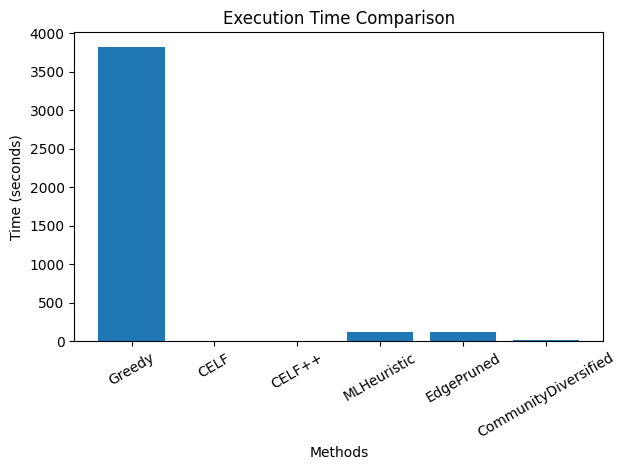

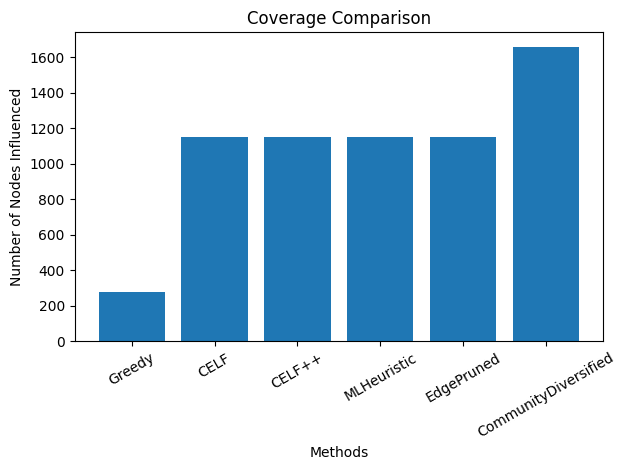

In [ ]:
# MAIN TEST
G = nx.barabasi_albert_graph(n=5000, m=3)

print("Number of nodes:", G.number_of_nodes())
print("Number of edges:", G.number_of_edges())

k = 10
results = run_experiment(G, k)
results

plot_results(results)

**Dataset 2: ca-GrQc (Nodes:5250, Edges:14500)**

In [ ]:
# Download the General Relativity and Quantum Cosmology collaboration network dataset
!wget -nc https://snap.stanford.edu/data/ca-GrQc.txt.gz
!gunzip -f ca-GrQc.txt.gz

--2026-05-07 13:56:12--  https://snap.stanford.edu/data/ca-GrQc.txt.gz
Resolving snap.stanford.edu (snap.stanford.edu)... 171.64.75.80
Connecting to snap.stanford.edu (snap.stanford.edu)|171.64.75.80|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 109261 (107K) [application/x-gzip]
Saving to: ‘ca-GrQc.txt.gz’

ca-GrQc.txt.gz      100%[===================>] 106.70K   308KB/s    in 0.3s    

2026-05-07 13:56:13 (308 KB/s) - ‘ca-GrQc.txt.gz’ saved [109261/109261]



In [ ]:
# Load the ca-GrQc graph
grqc_graph_file = 'ca-GrQc.txt'
grqc_G = load_large_graph(grqc_graph_file)

print("Number of nodes in ca-GrQc graph:", grqc_G.number_of_nodes())
print("Number of edges in ca-GrQc graph:", grqc_G.number_of_edges())

Number of nodes in ca-GrQc graph: 5242
Number of edges in ca-GrQc graph: 14496



Method: Greedy
Time: 4975.4596 sec
Coverage: 268
Selected Seeds: [9208, 21508, 22601, 23693, 16590, 17584, 3283, 7096, 24122, 20574]

Method: CELF
Time: 0.0131 sec
Coverage: 446
Selected Seeds: [7650, 13929, 13801, 22601, 15244, 4364, 21012, 2710, 14265, 2654]

Method: CELF++
Time: 0.0121 sec
Coverage: 446
Selected Seeds: [7650, 13929, 13801, 22601, 15244, 4364, 21012, 2710, 14265, 2654]

Method: MLHeuristic
Time: 106.3132 sec
Coverage: 438
Selected Seeds: [7650, 9639, 14599, 13801, 22601, 13929, 15244, 4364, 21012, 2654]

Method: EdgePruned
Time: 103.6745 sec
Coverage: 438
Selected Seeds: [7650, 9639, 14599, 13801, 22601, 13929, 15244, 4364, 21012, 2654]

Method: CommunityDiversified
Time: 14.0886 sec
Coverage: 1682
Selected Seeds: [12290, 2054, 12295, 9224, 13, 4110, 11280, 6161, 24594, 5137, 12307, 19473, 4116, 5144, 25, 7194, 21530, 15387, 6170, 1023, 20511, 12320, 5156, 15401, 13357, 19502, 14384, 4144, 19507, 19520, 25664, 25667, 1092, 23621, 2116, 2120, 22601, 21579, 25676, 103

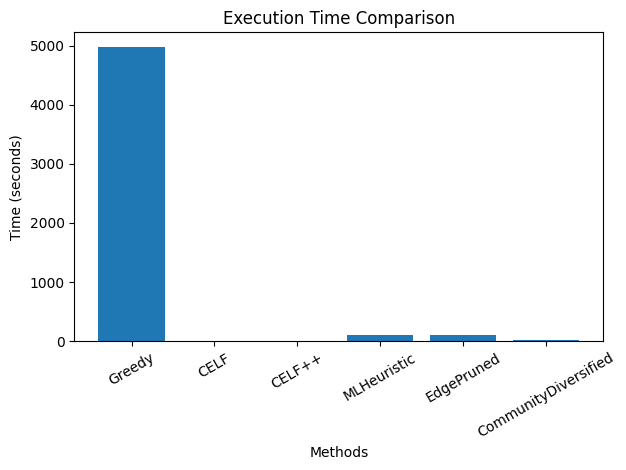

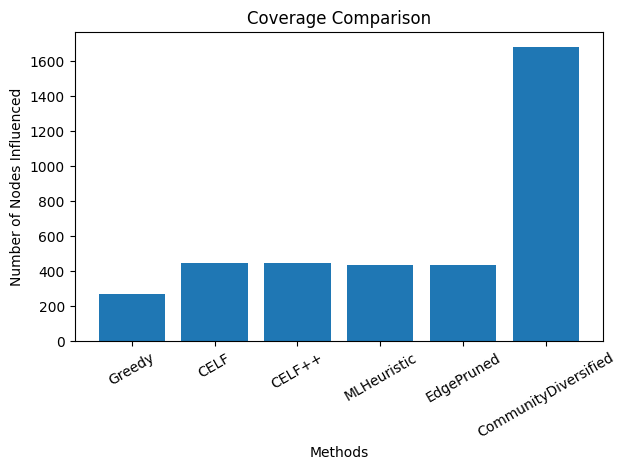

In [ ]:
k_grqc = 10 # Number of sensors to select
grqc_results = run_experiment(grqc_G, k_grqc)

plot_results(grqc_results)

**Dataset 3: Barabasi Albert Graph (Nodes:10000, Edges:100000)**

In [ ]:
# MAIN TEST
G = nx.barabasi_albert_graph(n=10000, m=10)

print("Number of nodes:", G.number_of_nodes())
print("Number of edges:", G.number_of_edges())

k = 10
results = run_experiment(G, k)
results

plot_results(results)

Number of nodes: 10000
Number of edges: 99900
